## HateXplain - 3 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification

* **Target 1:** Hate speech against African
* **Target 2:** Hate speech against Arab
* **Target 3:** Hate speech against Caucasian

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import dill
import pickle
import torch
from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
from machinemoo.utils.seed_config import set_np_torch_seed
set_np_torch_seed(42)

In [5]:
PREFIX_SAVE_IMAGE = 'images/3_objs'

In [6]:
PREFIX_SAVE_RESULT = '3_objs'

## Dataset and Model

In [7]:
# Get HateXplain Dataset
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# Choose BERT model
model_name="bert-base-uncased"

In [8]:
# Use GPU if its available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
task_config = {
    "African": {"type": "group_hate", "group": "African"},
    "Caucasian": {"type": "group_hate", "group": "Caucasian"},
    "Arab": {"type": "group_hate", "group": "Arab"},
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [10]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
objectives_names = list(task_config.keys())

# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

def machine_optimize(method, lb_estimate=0.01):
    w_scalar = NLPScalarization(
        train_dataloader = train_dataloader, 
        device = device, 
        task_names = objectives_names, 
        lower_bound_estimate=lb_estimate
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    "moopt": moopt,
                    "objectives": objs,
                    "models": get_models(moopt),
                    "hypervolume": hypervolume_values
                }


In [11]:
    
def plot_frontier(method, color="#d73027"):
    title="Loss Trade-offs in Multi-Group Hate Speech Detection"
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                color=color,
                fontsize=17,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

In [13]:
method = 'mola'
machine_optimize(method=method)

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


...

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


<Figure size 1000x700 with 0 Axes>

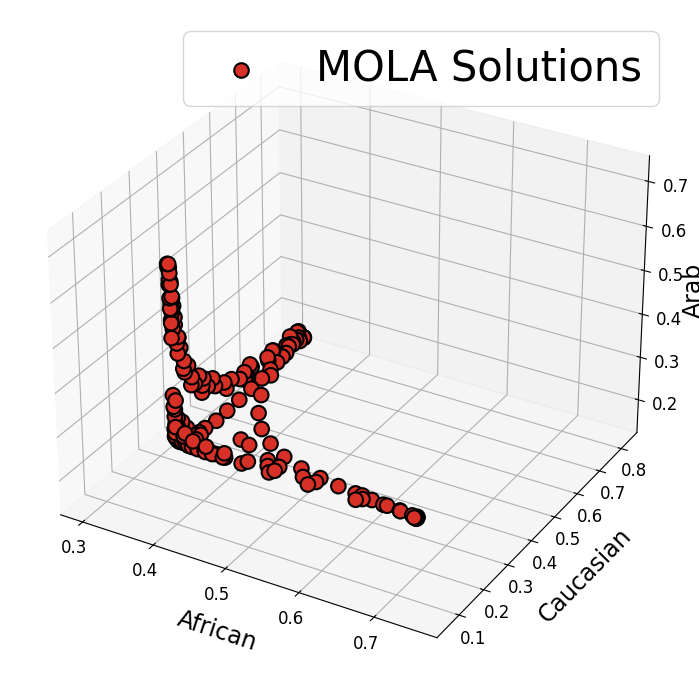

In [44]:
plot_frontier('mola', color='#d73027')

### MOLA with gradient

In [16]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

<Figure size 1000x700 with 0 Axes>

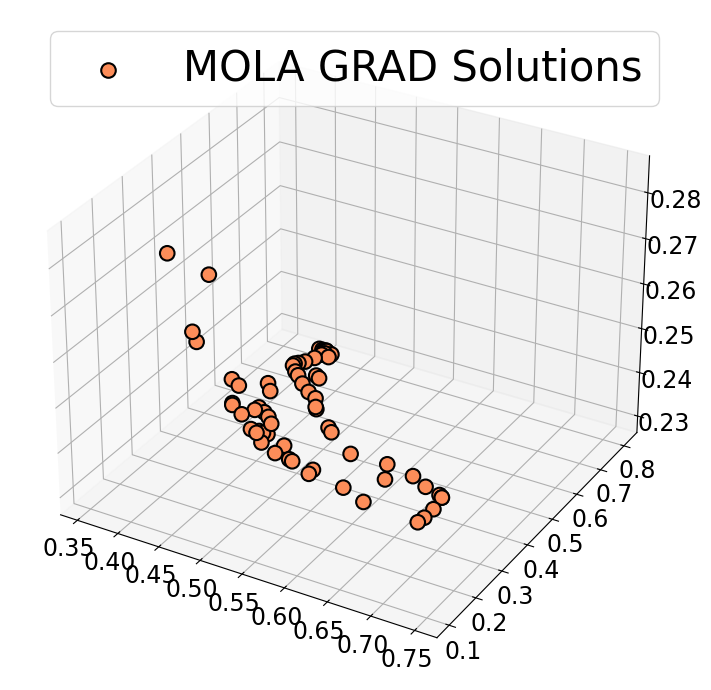

In [41]:
plot_frontier(f'mola_grad', color='#fc8d59')

### Random Weights

In [ ]:
method = 'random_weights'
machine_optimize(method=method)

### Non-dominated Solutions Analysis

In [ ]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weights']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')

Number of non-dominated solutions with MOLA          : 200
Number of non-dominated solutions with MOLA GRAD     : 71
Number of non-dominated solutions with RANDOM WEIGHT : 117


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 3000x700 with 0 Axes>

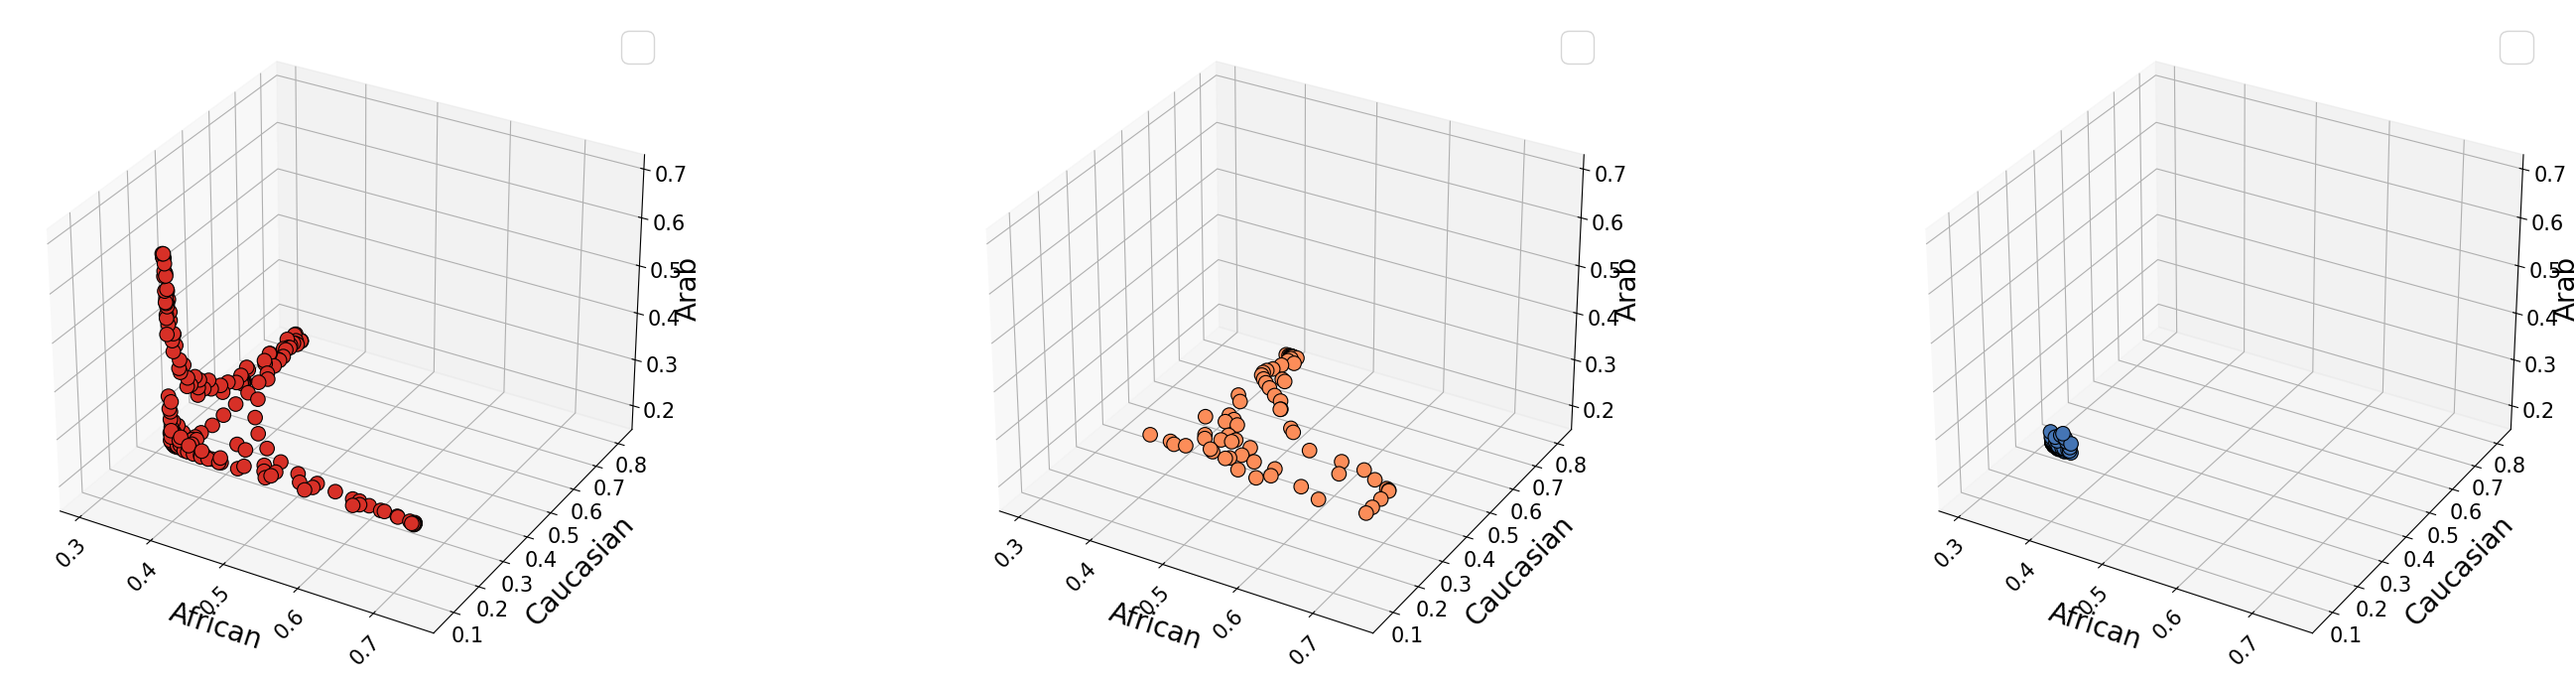

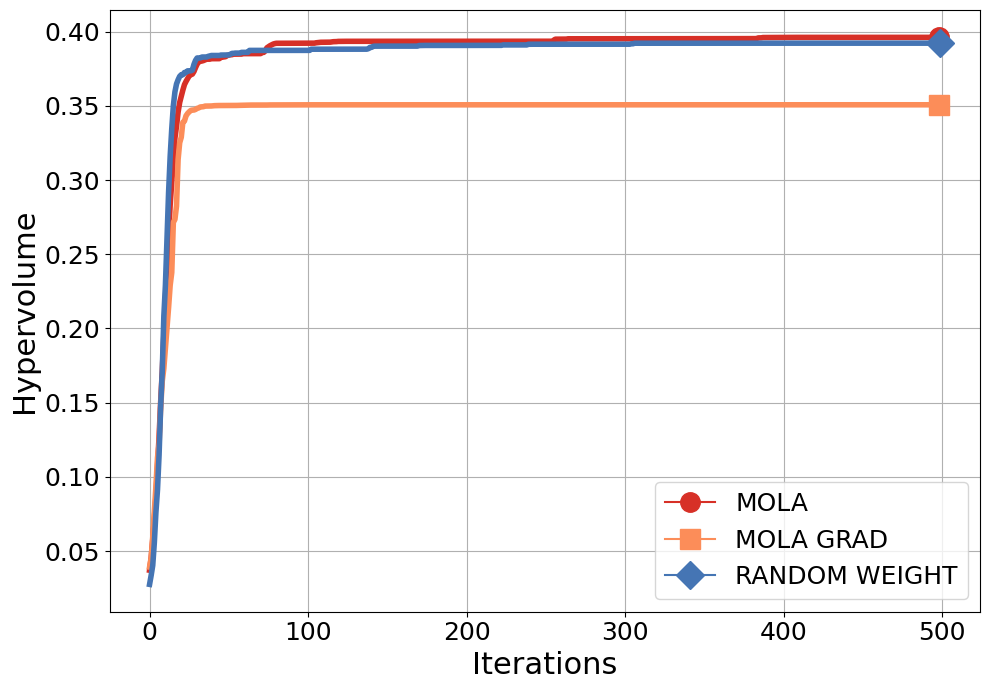

In [ ]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res
    }

pareto_dict['random_weights'] = rw_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            title='Comparative Pareto Frontiers Across MOO Methods',
            #subset=equal.objs,
            fontsize=20,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )


plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

In [ ]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

# get saved results
#with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "rb") as f:
#    results = pickle.load(f)

<Figure size 1000x700 with 0 Axes>

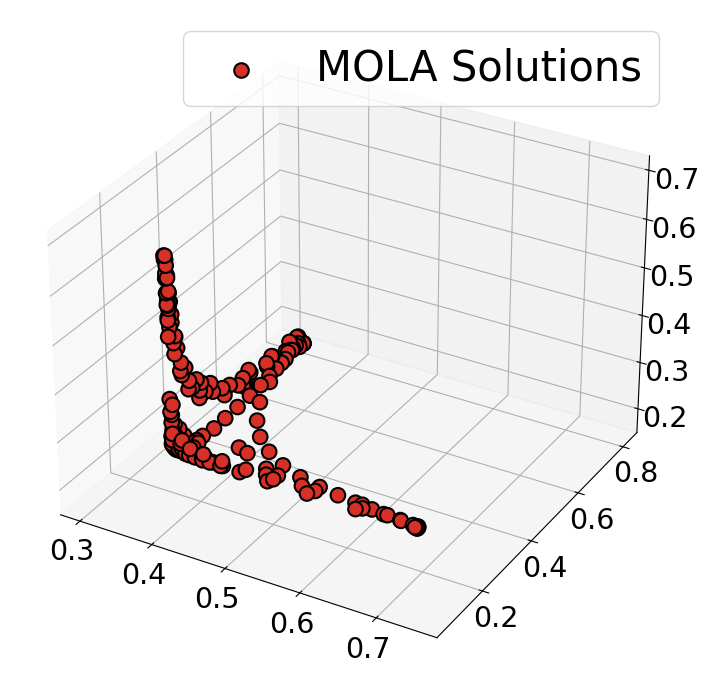

<Figure size 1000x700 with 0 Axes>

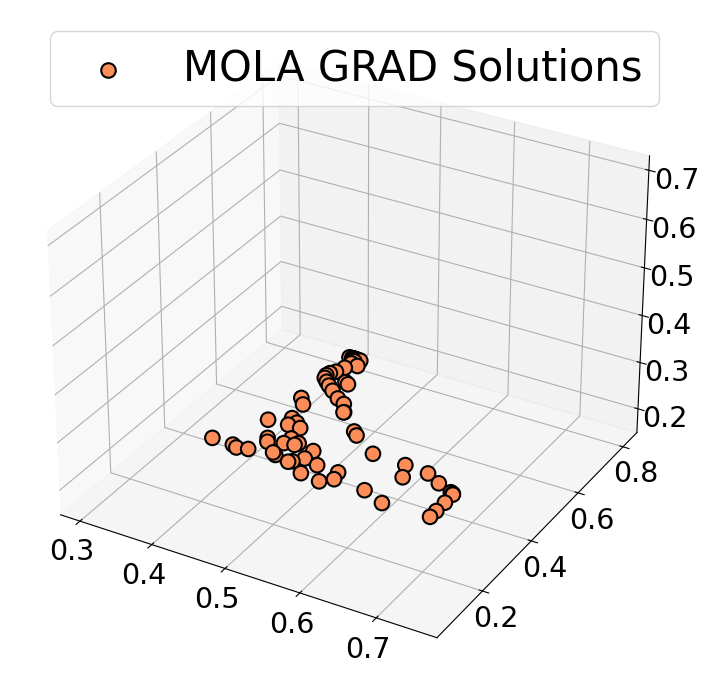

<Figure size 1000x700 with 0 Axes>

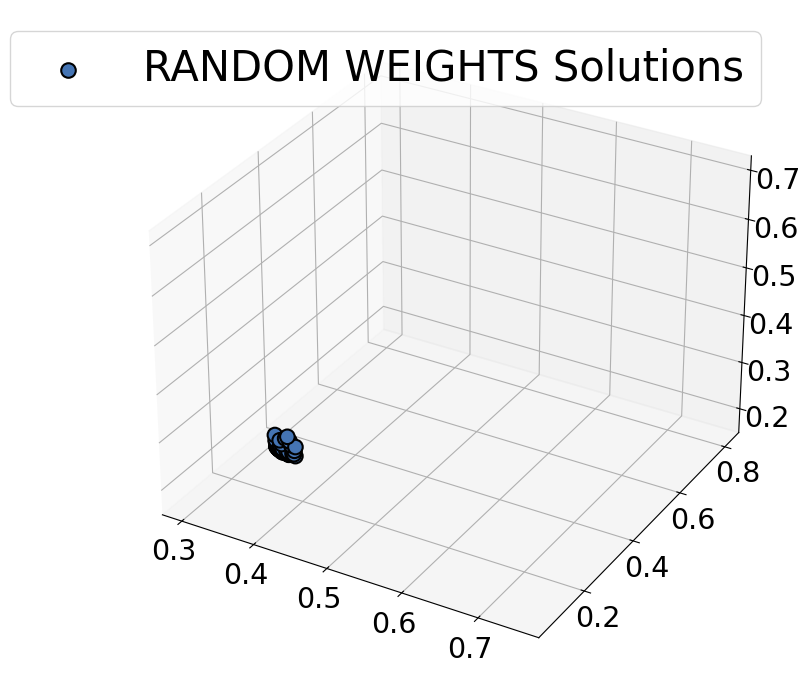

In [21]:
import numpy as np
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

first_objs =  np.vstack(list(pareto_dict.values()))
x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()
z_min, z_max = first_objs[:, 2].min() - first_objs[:, 2].std(), first_objs[:, 2].max() + first_objs[:, 2].std()

limits.append((x_min, x_max))
limits.append((y_min, y_max))
limits.append((z_min, z_max))

for i, (method, objs) in enumerate(pareto_dict.items()):
    plot_pareto(methods={method: objs},
                color = color[i],
                labels=objectives_names, 
                #title=title,
                fontsize=20,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}_limit.pdf',
                limits=limits
    )